# exp09 — Football Strength Model

**Nama Eksperimen:** `exp09_football_strength_model`  
**Output CSV:** `exp09_football_strength_model.csv`

## Filosofi Eksperimen

Eksperimen ini membangun fitur yang secara eksplisit merepresentasikan **kekuatan menyerang (attack strength)** dan **kekuatan bertahan (defense strength)** masing-masing tim. Pendekatan ini berangkat dari filosofi dasar sepak bola:

> *Berapa banyak gol yang dicetak suatu tim = f(attack strength tim, defense strength lawan, konteks pertandingan)*

### Komponen Kekuatan:
- **Attack Strength**: Rata-rata gol dicetak, form gol offensif, ELO, win rate
- **Defense Strength**: Rata-rata gol kemasukan, form defensif, GD defensif
- **Matchup Features**: Selisih kekuatan attack vs defense, head-to-head, tekanan ranking
- **Context Features**: Home advantage, altitude, travel distance, temperature, konfederasi

### Struktur Representasi:
Data sudah dalam format **row-wise per tim per pertandingan** (2 baris per match). Kita gunakan langsung karena tiap baris sudah merepresentasikan perspektif tim tersebut (team = attacking team, opponent = defending team).

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
np.random.seed(SEED)

# Paths
TRAIN_PATH = '../dataset/train.csv'
TEST_PATH  = '../dataset/test.csv'
OUT_CSV    = '../Submission/exp09_football_strength_model.csv'

print('Setup complete. Libraries loaded.')
print(f'LightGBM: {lgb.__version__}  |  XGBoost: {xgb.__version__}')

Setup complete. Libraries loaded.
LightGBM: 4.6.0  |  XGBoost: 3.1.2


---
## 2. Load Data

In [2]:
train_raw = pd.read_csv(TRAIN_PATH, parse_dates=['date'])
test_raw  = pd.read_csv(TEST_PATH,  parse_dates=['date'])

print(f'Train shape : {train_raw.shape}')
print(f'Test shape  : {test_raw.shape}')
print(f'Train date range: {train_raw["date"].min().date()} → {train_raw["date"].max().date()}')
print(f'Test  date range: {test_raw["date"].min().date()} → {test_raw["date"].max().date()}')
print(f'Train unique matches: {train_raw["match_id"].nunique()}')
print(f'Test  unique matches: {test_raw["match_id"].nunique()}')

Train shape : (78772, 47)
Test shape  : (42422, 20)
Train date range: 1872-11-30 → 2011-08-04
Test  date range: 2011-08-06 → 2026-03-31
Train unique matches: 39386
Test  unique matches: 21211


In [3]:
train_raw.head(4)

,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,team_goals,opp_goals,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,h2h_points_last5,h2h_gd_last5,days_since_last_match_team,days_since_last_match_opp,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,rank_missing_team,rank_missing_opp,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M000001_Scotland,M000001,1872-11-30,M,Scotland,England,1,0,Friendly,Scotland,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0000,1500.0000,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M000001_England,M000001,1872-11-30,M,England,Scotland,0,0,Friendly,Scotland,0,0,NaN,1.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,1.0000,NaN,NaN,0.0000,0.0000,NaN,0.0000,1500.0000,1500.0000,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M000002_England,M000002,1873-03-08,M,England,Scotland,1,0,Friendly,England,4,2,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,98.0000,98.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1500.0000,1500.0000,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M000002_Scotland,M000002,1873-03-08,M,Scotland,England,0,0,Friendly,England,2,4,1.0000,4.0000,-3.0000,0.0000,2.0000,-2.0000,1.0000,0.0000,98.0000,0.0000,1.0000,4.0000,0.0000,0.0000,2.0000,1.0000,0.0000,0.5000,1484.0000,1516.0000,NaN,NaN,NaN,1,1,UEFA,UEFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
test_raw.head(4)

,Id,match_id,date,gender,team,opponent,is_home,neutral,tournament,venue_country,confederation_team,confederation_opp,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,altitude_venue,distance_travel_team,distance_travel_opp,temperature_venue
0,M034984_Seychelles,M034984,2011-08-06,M,Seychelles,Mauritius,1,0,Indian Ocean Island Games,Seychelles,CAF,CAF,92409.0000,1283330.0000,12189.0952,9197.0270,-9999.0000,0.0000,1751.8957,25.7902
1,M034984_Mauritius,M034984,2011-08-06,M,Mauritius,Seychelles,0,0,Indian Ocean Island Games,Seychelles,CAF,CAF,1283330.0000,92409.0000,9197.0270,12189.0952,-9999.0000,1751.8957,0.0000,25.7902
2,M034985_Comoros,M034985,2011-08-06,M,Comoros,Maldives,1,1,Indian Ocean Island Games,Seychelles,CAF,AFC,656024.0000,361575.0000,1447.9451,7291.4660,-9999.0000,1517.0107,5483.1175,25.7902
3,M034985_Maldives,M034985,2011-08-06,M,Maldives,Comoros,0,1,Indian Ocean Island Games,Seychelles,AFC,CAF,361575.0000,656024.0000,7291.4660,1447.9451,-9999.0000,5483.1175,1517.0107,25.7902


---
## 3. EDA

In [5]:
print('=== TARGET DISTRIBUTION ===')
print('team_goals:')
print(train_raw['team_goals'].describe())
print('\nopp_goals:')
print(train_raw['opp_goals'].describe())

=== TARGET DISTRIBUTION ===
team_goals:
count   78772.0000
mean        1.5631
std         1.7921
min         0.0000
25%         0.0000
50%         1.0000
75%         2.0000
max        31.0000
Name: team_goals, dtype: float64

opp_goals:
count   78772.0000
mean        1.5631
std         1.7921
min         0.0000
25%         0.0000
50%         1.0000
75%         2.0000
max        31.0000
Name: opp_goals, dtype: float64


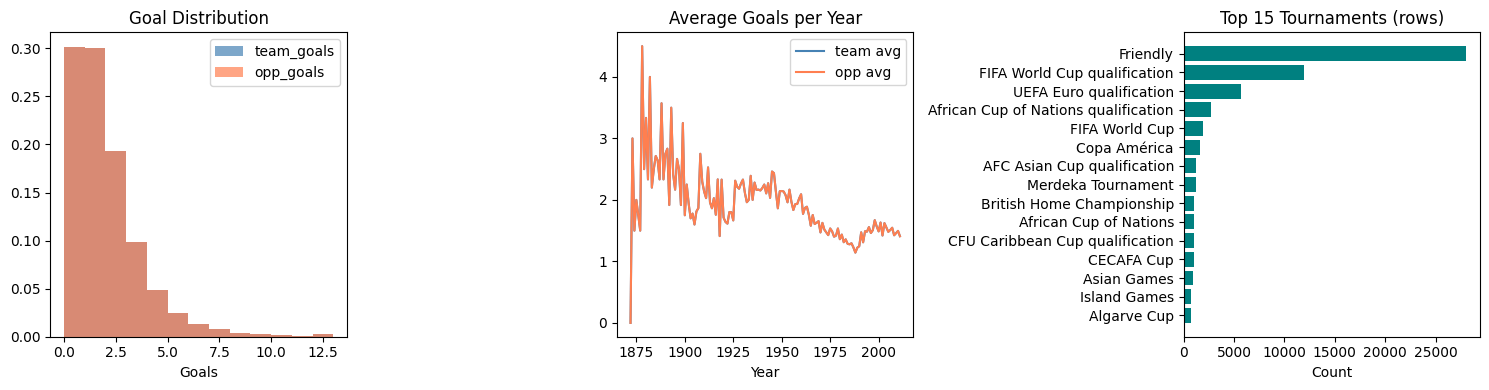

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Goal distributions
max_goals = 12
axes[0].hist(train_raw['team_goals'].clip(0, max_goals), bins=range(max_goals+2),
             alpha=0.7, label='team_goals', color='steelblue', density=True)
axes[0].hist(train_raw['opp_goals'].clip(0, max_goals), bins=range(max_goals+2),
             alpha=0.7, label='opp_goals', color='coral', density=True)
axes[0].set_title('Goal Distribution')
axes[0].set_xlabel('Goals')
axes[0].legend()

# Goals over time
yearly = train_raw.groupby(train_raw['date'].dt.year).agg(
    team_avg=('team_goals','mean'), opp_avg=('opp_goals','mean')).reset_index()
axes[1].plot(yearly['date'], yearly['team_avg'], label='team avg', color='steelblue')
axes[1].plot(yearly['date'], yearly['opp_avg'], label='opp avg', color='coral')
axes[1].set_title('Average Goals per Year')
axes[1].set_xlabel('Year')
axes[1].legend()

# Tournament distribution
top_tourn = train_raw['tournament'].value_counts().head(15)
axes[2].barh(top_tourn.index[::-1], top_tourn.values[::-1], color='teal')
axes[2].set_title('Top 15 Tournaments (rows)')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

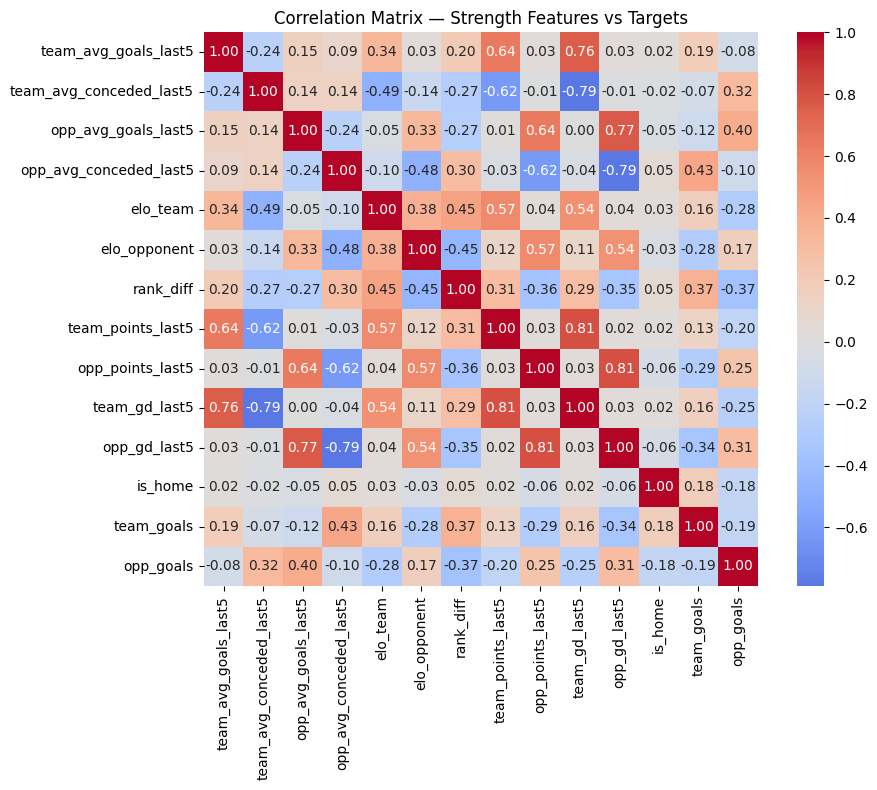

In [7]:
# Correlation: existing strength features vs targets
strength_cols = [
    'team_avg_goals_last5','team_avg_conceded_last5',
    'opp_avg_goals_last5','opp_avg_conceded_last5',
    'elo_team','elo_opponent','rank_diff',
    'team_points_last5','opp_points_last5',
    'team_gd_last5','opp_gd_last5',
    'is_home','team_goals','opp_goals'
]
corr = train_raw[strength_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Matrix — Strength Features vs Targets')
plt.tight_layout()
plt.show()

In [8]:
print('=== MISSING VALUE SUMMARY (TRAIN) ===')
miss = train_raw.isnull().sum()
miss_pct = (miss / len(train_raw) * 100).round(1)
miss_df = pd.DataFrame({'missing': miss, 'pct': miss_pct})
print(miss_df[miss_df['missing'] > 0].sort_values('pct', ascending=False))

=== MISSING VALUE SUMMARY (TRAIN) ===
                            missing     pct
rank_diff                     43902 55.7000
rank_team                     41946 53.2000
rank_opponent                 41946 53.2000
distance_travel_opp           30392 38.6000
distance_travel_team          30392 38.6000
gdp_per_capita_opp            25957 33.0000
gdp_per_capita_team           25957 33.0000
altitude_venue                20554 26.1000
temperature_venue             17074 21.7000
population_team               14872 18.9000
population_opp                14872 18.9000
h2h_gd_last5                  11976 15.2000
h2h_points_last5              11976 15.2000
gd_last5_diff                   440  0.6000
points_last5_diff               440  0.6000
team_points_last5               294  0.4000
team_avg_conceded_last5         294  0.4000
days_since_last_match_team      294  0.4000
team_gd_last5                   294  0.4000
team_avg_goals_last5            294  0.4000
team_points_last10              294  0

In [9]:
# Home advantage analysis
home = train_raw[train_raw['is_home'] == 1]
away = train_raw[train_raw['is_home'] == 0]
neutral = train_raw[train_raw['neutral'] == 1]

print('=== HOME/AWAY/NEUTRAL ADVANTAGE ===')
print(f'Home  avg team_goals: {home["team_goals"].mean():.3f}  opp_goals: {home["opp_goals"].mean():.3f}')
print(f'Away  avg team_goals: {away["team_goals"].mean():.3f}  opp_goals: {away["opp_goals"].mean():.3f}')
print(f'Neut  avg team_goals: {neutral["team_goals"].mean():.3f}  opp_goals: {neutral["opp_goals"].mean():.3f}')

=== HOME/AWAY/NEUTRAL ADVANTAGE ===
Home  avg team_goals: 1.889  opp_goals: 1.238
Away  avg team_goals: 1.238  opp_goals: 1.889
Neut  avg team_goals: 1.658  opp_goals: 1.658


---
## 4. Validation Strategy

**Strategi: Time-based split dengan Match-ID grouping (anti-leakage)**

- Sort match unik berdasarkan `date`
- 80% match pertama = train fold, 20% match terakhir = validation fold
- Pastikan semua baris dengan `match_id` yang sama berada di fold yang sama
- Ini mencegah leakage karena pertandingan tidak terpecah antara train dan val

In [10]:
# Get unique matches sorted by date
match_dates = train_raw.groupby('match_id')['date'].min().sort_values()
n_matches = len(match_dates)
split_idx = int(n_matches * 0.80)

train_match_ids = set(match_dates.iloc[:split_idx].index)
val_match_ids   = set(match_dates.iloc[split_idx:].index)

train_fold = train_raw[train_raw['match_id'].isin(train_match_ids)].copy()
val_fold   = train_raw[train_raw['match_id'].isin(val_match_ids)].copy()

print(f'Total matches      : {n_matches}')
print(f'Train fold matches : {len(train_match_ids)} ({len(train_fold)} rows)')
print(f'Val   fold matches : {len(val_match_ids)}   ({len(val_fold)} rows)')
print(f'Train date: {train_fold["date"].min().date()} → {train_fold["date"].max().date()}')
print(f'Val   date: {val_fold["date"].min().date()} → {val_fold["date"].max().date()}')

# Verify zero overlap
overlap = train_match_ids & val_match_ids
assert len(overlap) == 0, f'LEAKAGE: {len(overlap)} matches in both folds!'
print('\n✓ Zero match_id overlap between train and validation folds.')

Total matches      : 39386
Train fold matches : 31508 (63016 rows)
Val   fold matches : 7878   (15756 rows)
Train date: 1872-11-30 → 2005-01-30
Val   date: 2005-02-01 → 2011-08-04

✓ Zero match_id overlap between train and validation folds.


---
## 5. Official AW-MAE Evaluator

Implementasi evaluator resmi sesuai formula kompetisi. Setiap pertandingan dihitung **satu kali** menggunakan `match_id` (canonical scoring).

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# TOURNAMENT WEIGHTING
# ─────────────────────────────────────────────────────────────────────────────
TOURNAMENT_WEIGHT_MAP = {
    'fifa world cup': 2.00,
    'world cup': 2.00,
    'afc championship': 1.80,
    'afc asian cup': 1.80,
    'asian cup': 1.80,
    'friendly match': 0.96,
    'friendly': 0.96,
    'international friendly': 0.96,
}
DEFAULT_WEIGHT = 1.20

def get_tournament_weight(tournament_name: str) -> float:
    """Robust keyword-based tournament weighting (case-insensitive)."""
    if pd.isna(tournament_name):
        return DEFAULT_WEIGHT
    t = str(tournament_name).lower().strip()
    # Exact match first
    if t in TOURNAMENT_WEIGHT_MAP:
        return TOURNAMENT_WEIGHT_MAP[t]
    # Keyword matching (longest key wins)
    best_key = None
    for key in sorted(TOURNAMENT_WEIGHT_MAP, key=len, reverse=True):
        if key in t:
            best_key = key
            break
    return TOURNAMENT_WEIGHT_MAP[best_key] if best_key else DEFAULT_WEIGHT

# Quick sanity checks
assert get_tournament_weight('FIFA World Cup') == 2.00
assert get_tournament_weight('Friendly Match') == 0.96
assert get_tournament_weight('Friendly') == 0.96
assert get_tournament_weight('AFC Asian Cup') == 1.80
assert get_tournament_weight('CONCACAF Gold Cup') == DEFAULT_WEIGHT
print('Tournament weight function verified.')

Tournament weight function verified.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# OFFICIAL AW-MAE EVALUATOR
# ─────────────────────────────────────────────────────────────────────────────
def compute_awmae(df_val: pd.DataFrame,
                  team_pred: np.ndarray,
                  opp_pred:  np.ndarray,
                  verbose: bool = False) -> dict:
    """
    Official AW-MAE evaluator.

    Inputs
    ------
    df_val     : validation dataframe (must have match_id, tournament,
                 team_goals, opp_goals, and optionally Id)
    team_pred  : integer predictions for team_goals (same row order as df_val)
    opp_pred   : integer predictions for opp_goals  (same row order as df_val)

    Returns
    -------
    dict with AW-MAE and diagnostic metrics, canonical scoring per match_id
    """
    df = df_val.copy().reset_index(drop=True)
    df['_tg_pred'] = team_pred
    df['_og_pred'] = opp_pred

    # ── Canonical: one row per match (perspective of the 'home'/'first' team)
    # We choose the row where Id ends with the team name (first encountered per match)
    df_match = df.groupby('match_id').first().reset_index()

    results = []
    for _, row in df_match.iterrows():
        tg_true = int(row['team_goals'])
        og_true = int(row['opp_goals'])
        tg_pred = int(row['_tg_pred'])
        og_pred = int(row['_og_pred'])
        tournament = row['tournament']

        # Base MAE per match
        base_mae = (abs(tg_true - tg_pred) + abs(og_true - og_pred)) / 2.0

        # Component flags
        exact   = 1 if (tg_true == tg_pred and og_true == og_pred) else 0

        def outcome(g, og):
            if g > og: return 'W'
            elif g == og: return 'D'
            else: return 'L'
        outcome_ok  = 1 if outcome(tg_true, og_true) == outcome(tg_pred, og_pred) else 0
        gd_true = tg_true - og_true
        gd_pred = tg_pred - og_pred
        gd_ok   = 1 if gd_true == gd_pred else 0

        # Penalty
        penalty = 0.30 * (1 - exact) + 0.25 * (1 - outcome_ok) + 0.15 * (1 - gd_ok)

        # Outcome multiplier
        multiplier = 1.0 if outcome_ok else 1.5

        # Non-linear loss
        raw_loss = base_mae + penalty
        loss = (raw_loss * multiplier) ** 1.5

        # Tournament weight
        weight = get_tournament_weight(tournament)

        results.append({
            'match_id': row['match_id'],
            'base_mae': base_mae,
            'exact': exact,
            'outcome_ok': outcome_ok,
            'gd_ok': gd_ok,
            'penalty': penalty,
            'multiplier': multiplier,
            'raw_loss': raw_loss,
            'loss': loss,
            'weight': weight,
        })

    res = pd.DataFrame(results)

    # AW-MAE
    awmae = np.sum(res['loss'] * res['weight']) / np.sum(res['weight'])

    # Diagnostic metrics
    diagnostics = {
        'AW-MAE':           awmae,
        'base_MAE':         res['base_mae'].mean(),
        'exact_score_rate': res['exact'].mean(),
        'outcome_acc':      res['outcome_ok'].mean(),
        'gd_acc':           res['gd_ok'].mean(),
        'n_matches':        len(res),
    }

    if verbose:
        print(f"  AW-MAE           : {awmae:.5f}")
        print(f"  Base MAE         : {res['base_mae'].mean():.5f}")
        print(f"  Exact Score Rate : {res['exact'].mean():.4f}")
        print(f"  Outcome Accuracy : {res['outcome_ok'].mean():.4f}")
        print(f"  GD Accuracy      : {res['gd_ok'].mean():.4f}")
        print(f"  N matches eval   : {len(res)}")

    return diagnostics

print('AW-MAE evaluator defined.')

AW-MAE evaluator defined.


In [13]:
# ── Sanity check evaluator with a trivial "predict 1-0 always" baseline
val_check = val_fold.copy()
trivial_tg = np.ones(len(val_check), dtype=int)
trivial_og = np.zeros(len(val_check), dtype=int)
diag = compute_awmae(val_check, trivial_tg, trivial_og, verbose=True)
print('\n✓ Evaluator sanity check passed (trivial 1-0 baseline above).')

  AW-MAE           : 3.99907
  Base MAE         : 1.24746
  Exact Score Rate : 0.0990
  Outcome Accuracy : 0.4919
  GD Accuracy      : 0.1974
  N matches eval   : 7878

✓ Evaluator sanity check passed (trivial 1-0 baseline above).


---
## 6. Preprocessing

### Strategi Encoding
- Kolom kategorik (team, opponent, tournament, confederation, venue_country): Label Encoding
- Missing values: median imputation untuk numerik
- Untuk test data: recompute historical strength features dari train

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# TEAM STRENGTH LOOKUP — computed from ALL of train_raw
# (used for test inference)
# ─────────────────────────────────────────────────────────────────────────────

def compute_team_strength_lookup(df: pd.DataFrame, n_last: int = 10) -> dict:
    """
    For each team, compute recent strength features from their last n_last matches.
    Returns a dict: team_name -> feature_dict
    """
    df = df.sort_values('date').reset_index(drop=True)
    lookup = {}

    for team, grp in df.groupby('team'):
        n5  = grp.tail(5)
        n10 = grp.tail(10)

        goals5  = n5['team_goals'].mean()   if len(n5)  > 0 else np.nan
        conc5   = n5['opp_goals'].mean()    if len(n5)  > 0 else np.nan
        gd5     = (n5['team_goals'] - n5['opp_goals']).sum() if len(n5) > 0 else np.nan
        wins5   = (n5['team_goals'] > n5['opp_goals']).sum() if len(n5) > 0 else np.nan
        draws5  = (n5['team_goals'] == n5['opp_goals']).sum() if len(n5) > 0 else np.nan
        pts5    = (wins5 * 3 + draws5) if pd.notna(wins5) else np.nan

        goals10  = n10['team_goals'].mean()  if len(n10) > 0 else np.nan
        conc10   = n10['opp_goals'].mean()   if len(n10) > 0 else np.nan
        win_rate10 = (n10['team_goals'] > n10['opp_goals']).mean() if len(n10) > 0 else np.nan
        pts10    = (n10['team_goals'] > n10['opp_goals']).sum() * 3 + \
                   (n10['team_goals'] == n10['opp_goals']).sum() if len(n10) > 0 else np.nan

        # Last known ELO and rank
        last_elo  = grp['elo_team'].iloc[-1]  if 'elo_team' in grp.columns else np.nan
        last_rank = grp['rank_team'].iloc[-1] if 'rank_team' in grp.columns else np.nan

        lookup[team] = {
            'team_avg_goals_last5':    goals5,
            'team_avg_conceded_last5': conc5,
            'team_gd_last5':           gd5,
            'team_points_last5':       pts5,
            'team_avg_goals_last10':   goals10,
            'team_avg_conceded_last10':conc10,
            'team_win_rate_last10':    win_rate10,
            'team_points_last10':      pts10,
            'elo_team':                last_elo,
            'rank_team':               last_rank,
        }
    return lookup

# Build lookup from FULL train_raw (for test inference)
strength_lookup = compute_team_strength_lookup(train_raw)
print(f'Strength lookup built for {len(strength_lookup)} teams.')

Strength lookup built for 294 teams.


In [15]:
def get_team_feature(team: str, feat: str, lookup: dict, fallback_global: dict) -> float:
    """Safely fetch a feature from lookup, fall back to global mean."""
    if team in lookup and pd.notna(lookup[team].get(feat, np.nan)):
        return lookup[team][feat]
    return fallback_global.get(feat, np.nan)

# Global fallbacks (overall means from train_raw)
global_fallback = {
    'team_avg_goals_last5':     train_raw['team_avg_goals_last5'].mean(),
    'team_avg_conceded_last5':  train_raw['team_avg_conceded_last5'].mean(),
    'team_gd_last5':            train_raw['team_gd_last5'].mean(),
    'team_points_last5':        train_raw['team_points_last5'].mean(),
    'team_avg_goals_last10':    train_raw['team_avg_goals_last5'].mean(),  # proxy
    'team_avg_conceded_last10': train_raw['team_avg_conceded_last5'].mean(),
    'team_win_rate_last10':     train_raw['team_win_rate_last10'].mean(),
    'team_points_last10':       train_raw['team_points_last10'].mean(),
    'elo_team':                 train_raw['elo_team'].mean(),
    'rank_team':                train_raw['rank_team'].mean(),
}
print('Global fallback values computed.')

Global fallback values computed.


---
## 7. Feature Engineering

### Filosofi Fitur Sepak Bola

| Kategori | Fitur | Alasan |
|---|---|---|
| **Attack Strength** | avg_goals_last5, avg_goals_last10 | Kapasitas mencetak gol tim |
| **Defense Strength** | avg_conceded_last5, avg_conceded_last10 | Kelemahan defensive |
| **Matchup** | attack_minus_opp_def, opp_attack_minus_def | Selisih kekuatan langsung |
| **Form** | points_last5, gd_last5, form_diff | Momentum terkini |
| **Quality** | elo_diff, rank_diff | Perbedaan kualitas absolut |
| **Head-to-Head** | h2h_points, h2h_gd | Historis duel langsung |
| **Context** | is_home, neutral, altitude, distance, temperature | Kondisi pertandingan |
| **Demographics** | confederation, population, gdp | Kekuatan infrastruktur sepak bola |

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

CAT_COLS = ['tournament', 'confederation_team', 'confederation_opp', 'gender', 'venue_country']

# Fit label encoders on full train_raw
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    # Fit on union of train + test values
    all_vals = pd.concat([train_raw[col].astype(str), test_raw[col].astype(str)]).unique()
    le.fit(all_vals)
    label_encoders[col] = le

print('Label encoders fitted.')


def build_features(df: pd.DataFrame,
                   label_encoders: dict,
                   strength_lookup: dict = None,
                   global_fallback: dict = None,
                   is_test: bool = False) -> pd.DataFrame:
    """
    Build full feature matrix from a dataframe.
    
    For is_test=True, computes strength features from lookup
    (since test.csv doesn't have historical columns).
    For is_test=False, uses pre-computed columns from train.
    """
    out = df.copy().reset_index(drop=True)

    # ── STEP 1: Fill strength features from lookup if test ──────────────────
    if is_test:
        # Team features from lookup
        feats_from_lookup = [
            'team_avg_goals_last5', 'team_avg_conceded_last5',
            'team_gd_last5', 'team_points_last5',
            'team_avg_goals_last10', 'team_avg_conceded_last10',
            'team_win_rate_last10', 'team_points_last10',
            'elo_team', 'rank_team',
        ]
        for feat in feats_from_lookup:
            out[feat] = out['team'].apply(
                lambda t: get_team_feature(t, feat, strength_lookup, global_fallback))

        # Opponent features — remap opp_* from team lookup
        opp_feat_map = {
            'opp_avg_goals_last5':    'team_avg_goals_last5',
            'opp_avg_conceded_last5': 'team_avg_conceded_last5',
            'opp_gd_last5':           'team_gd_last5',
            'opp_points_last5':       'team_points_last5',
            'opp_avg_goals_last10':   'team_avg_goals_last10',
            'opp_avg_conceded_last10':'team_avg_conceded_last10',
            'opp_win_rate_last10':    'team_win_rate_last10',
            'opp_points_last10':      'team_points_last10',
            'elo_opponent':           'elo_team',
            'rank_opponent':          'rank_team',
        }
        for out_col, lookup_key in opp_feat_map.items():
            out[out_col] = out['opponent'].apply(
                lambda t: get_team_feature(t, lookup_key, strength_lookup, global_fallback))

        # Derived from lookup
        out['rank_diff']              = out['rank_team'] - out['rank_opponent']
        out['points_last5_diff']      = out['team_points_last5'] - out['opp_points_last5']
        out['gd_last5_diff']          = out['team_gd_last5'] - out['opp_gd_last5']
        out['team_points_last10']     = out['team_points_last10']
        out['opp_points_last10']      = out['opp_points_last10']
        out['rank_missing_team']      = out['rank_team'].isna().astype(int)
        out['rank_missing_opp']       = out['rank_opponent'].isna().astype(int)
        # No H2H available for test; fill with 0
        out['h2h_points_last5']       = 0.0
        out['h2h_gd_last5']           = 0.0
        out['days_since_last_match_team'] = np.nan
        out['days_since_last_match_opp']  = np.nan
    else:
        # For train: compute last10 goals from available columns if not present
        if 'team_avg_goals_last10' not in out.columns:
            # approximate from last10 win rate + gd — use last5 as proxy
            out['team_avg_goals_last10'] = out.get('team_avg_goals_last5', np.nan)
            out['opp_avg_goals_last10']  = out.get('opp_avg_goals_last5', np.nan)
            out['team_avg_conceded_last10'] = out.get('team_avg_conceded_last5', np.nan)
            out['opp_avg_conceded_last10']  = out.get('opp_avg_conceded_last5', np.nan)

    # ── STEP 2: Core Strength Matchup Features ───────────────────────────────
    # Attack minus opponent defense
    out['attack_vs_opp_def'] = out['team_avg_goals_last5'] - out['opp_avg_conceded_last5']
    # Opponent attack minus our defense
    out['opp_attack_vs_def'] = out['opp_avg_goals_last5'] - out['team_avg_conceded_last5']
    # Expected goal diff
    out['expected_gd'] = out['attack_vs_opp_def'] - out['opp_attack_vs_def']

    # ── STEP 3: Form Features ────────────────────────────────────────────────
    out['form_diff']   = out['team_points_last5'] - out['opp_points_last5']
    out['gd_form_diff']= out['team_gd_last5']     - out['opp_gd_last5']

    # ── STEP 4: ELO & Ranking Features ──────────────────────────────────────
    out['elo_diff'] = out['elo_team'] - out['elo_opponent']
    out['elo_ratio']= out['elo_team'] / (out['elo_opponent'] + 1e-5)

    # ── STEP 5: Pressure / Matchup Composite ────────────────────────────────
    # Home pressure: home + attack advantage
    out['home_attack_pressure'] = out['is_home'] * out['attack_vs_opp_def'].clip(-5, 5)
    # Quality gap pressure
    out['quality_gap'] = out['elo_diff'] / 100.0  # normalized
    # Defense vs offense synergy
    out['def_offense_ratio'] = (
        out['team_avg_goals_last5'].fillna(0) /
        (out['team_avg_conceded_last5'].fillna(1) + 0.1))
    out['opp_def_offense_ratio'] = (
        out['opp_avg_goals_last5'].fillna(0) /
        (out['opp_avg_conceded_last5'].fillna(1) + 0.1))

    # ── STEP 6: Context Features ─────────────────────────────────────────────
    out['altitude_venue'] = out['altitude_venue'].replace(-9999, np.nan)
    out['log_population_team'] = np.log1p(out['population_team'].fillna(0))
    out['log_population_opp']  = np.log1p(out['population_opp'].fillna(0))
    out['log_gdp_team'] = np.log1p(out['gdp_per_capita_team'].fillna(0))
    out['log_gdp_opp']  = np.log1p(out['gdp_per_capita_opp'].fillna(0))
    out['gdp_diff']     = out['log_gdp_team'] - out['log_gdp_opp']
    out['tournament_weight'] = out['tournament'].apply(get_tournament_weight)

    # ── STEP 7: Temporal features ────────────────────────────────────────────
    out['year']  = out['date'].dt.year
    out['month'] = out['date'].dt.month
    out['is_summer'] = out['month'].isin([6, 7, 8]).astype(int)

    # ── STEP 8: Categorical encoding ─────────────────────────────────────────
    for col in CAT_COLS:
        le = label_encoders[col]
        out[col + '_enc'] = le.transform(out[col].astype(str).fillna('UNKNOWN'))

    return out


print('Feature engineering pipeline defined.')

Label encoders fitted.
Feature engineering pipeline defined.


In [17]:
# Feature columns to use in model
FEATURE_COLS = [
    # Raw strength features
    'team_avg_goals_last5',
    'team_avg_conceded_last5',
    'opp_avg_goals_last5',
    'opp_avg_conceded_last5',
    'team_points_last5',
    'opp_points_last5',
    'team_gd_last5',
    'opp_gd_last5',
    'team_points_last10',
    'opp_points_last10',
    'team_win_rate_last10',
    'opp_win_rate_last10',
    # Matchup / Derived strength features
    'attack_vs_opp_def',
    'opp_attack_vs_def',
    'expected_gd',
    'form_diff',
    'gd_form_diff',
    # ELO & Ranking
    'elo_team',
    'elo_opponent',
    'elo_diff',
    'elo_ratio',
    'rank_diff',
    'rank_missing_team',
    'rank_missing_opp',
    # Pressure / Composite
    'home_attack_pressure',
    'quality_gap',
    'def_offense_ratio',
    'opp_def_offense_ratio',
    # H2H
    'h2h_points_last5',
    'h2h_gd_last5',
    # Context
    'is_home',
    'neutral',
    'altitude_venue',
    'distance_travel_team',
    'distance_travel_opp',
    'temperature_venue',
    'log_population_team',
    'log_population_opp',
    'log_gdp_team',
    'log_gdp_opp',
    'gdp_diff',
    'tournament_weight',
    # Temporal
    'year',
    'month',
    'is_summer',
    # Categorical
    'tournament_enc',
    'confederation_team_enc',
    'confederation_opp_enc',
    'gender_enc',
    'days_since_last_match_team',
    'days_since_last_match_opp',
]

print(f'Total features: {len(FEATURE_COLS)}')

Total features: 51


In [18]:
# Build feature matrices for train and val folds
train_fe  = build_features(train_fold, label_encoders, is_test=False)
val_fe    = build_features(val_fold,   label_encoders, is_test=False)

# Also build for full train (for final model)
full_train_fe = build_features(train_raw, label_encoders, is_test=False)

# Build for test
test_fe = build_features(test_raw, label_encoders, strength_lookup, global_fallback, is_test=True)

print(f'Train features shape : {train_fe.shape}')
print(f'Val   features shape : {val_fe.shape}')
print(f'Test  features shape : {test_fe.shape}')

# Verify all feature cols exist
missing_in_train = [c for c in FEATURE_COLS if c not in train_fe.columns]
missing_in_test  = [c for c in FEATURE_COLS if c not in test_fe.columns]
print(f'\nMissing in train: {missing_in_train}')
print(f'Missing in test : {missing_in_test}')

Train features shape : (63016, 76)
Val   features shape : (15756, 76)
Test  features shape : (42422, 74)

Missing in train: []
Missing in test : []


In [19]:
# Extract feature matrices and targets
X_train = train_fe[FEATURE_COLS].copy()
y_train_tg = train_fe['team_goals'].values
y_train_og = train_fe['opp_goals'].values

X_val = val_fe[FEATURE_COLS].copy()
y_val_tg = val_fe['team_goals'].values
y_val_og = val_fe['opp_goals'].values

X_full = full_train_fe[FEATURE_COLS].copy()
y_full_tg = full_train_fe['team_goals'].values
y_full_og = full_train_fe['opp_goals'].values

X_test = test_fe[FEATURE_COLS].copy()

print('Feature matrices ready.')
print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

Feature matrices ready.
X_train: (63016, 51)  X_val: (15756, 51)  X_test: (42422, 51)


---
## 8. Modeling

Dua model independen:
1. **LGB_TG** — LightGBM meramalkan `team_goals`
2. **LGB_OG** — LightGBM meramalkan `opp_goals`

Pemilihan hyperparameter dan strategi blending dioptimalkan terhadap **AW-MAE validation**, bukan MAE biasa.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# LIGHTGBM PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────

lgb_params_tg = {
    'objective':         'regression',
    'metric':            'mae',
    'learning_rate':     0.03,
    'n_estimators':      2000,
    'num_leaves':        63,
    'max_depth':         -1,
    'subsample':         0.80,
    'colsample_bytree':  0.75,
    'reg_alpha':         0.10,
    'reg_lambda':        1.00,
    'min_child_samples': 20,
    'random_state':      SEED,
    'verbose':           -1,
    'n_jobs':            -1,
}

lgb_params_og = {
    'objective':         'regression',
    'metric':            'mae',
    'learning_rate':     0.03,
    'n_estimators':      2000,
    'num_leaves':        63,
    'max_depth':         -1,
    'subsample':         0.80,
    'colsample_bytree':  0.75,
    'reg_alpha':         0.10,
    'reg_lambda':        1.00,
    'min_child_samples': 20,
    'random_state':      SEED,
    'verbose':           -1,
    'n_jobs':            -1,
}

print('LightGBM parameters set.')

LightGBM parameters set.


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN VALIDATION MODELS
# ─────────────────────────────────────────────────────────────────────────────

print('Training LGB for team_goals ...')
model_tg_val = lgb.LGBMRegressor(**lgb_params_tg)
model_tg_val.fit(
    X_train, y_train_tg,
    eval_set=[(X_val, y_val_tg)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)]
)
print(f'  Best iteration (team_goals): {model_tg_val.best_iteration_}')

print('Training LGB for opp_goals  ...')
model_og_val = lgb.LGBMRegressor(**lgb_params_og)
model_og_val.fit(
    X_train, y_train_og,
    eval_set=[(X_val, y_val_og)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)]
)
print(f'  Best iteration (opp_goals) : {model_og_val.best_iteration_}')

Training LGB for team_goals ...
  Best iteration (team_goals): 499
Training LGB for opp_goals  ...
  Best iteration (opp_goals) : 393


---
## 9. Post-processing

Model regresi menghasilkan nilai kontinu. Post-processing wajib:
1. **Clipping** — minimum 0, tidak ada gol negatif
2. **Rounding** — ke integer terdekat
3. **Safe cast** — integer conversion

In [22]:
def postprocess(pred: np.ndarray, min_val: int = 0) -> np.ndarray:
    """Clip to min, round to nearest integer, safe int cast."""
    clipped = np.clip(pred, min_val, None)
    rounded = np.round(clipped).astype(int)
    return rounded

print('Post-processing function defined.')
print('Strategy: clip(min=0) → round → int')

Post-processing function defined.
Strategy: clip(min=0) → round → int


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# VALIDATION PREDICTIONS
# ─────────────────────────────────────────────────────────────────────────────

val_pred_tg_raw = model_tg_val.predict(X_val)
val_pred_og_raw = model_og_val.predict(X_val)

val_pred_tg = postprocess(val_pred_tg_raw)
val_pred_og = postprocess(val_pred_og_raw)

print('Validation predictions (continuous):')
print(f'  team_goals mean: {val_pred_tg_raw.mean():.3f}  std: {val_pred_tg_raw.std():.3f}')
print(f'  opp_goals  mean: {val_pred_og_raw.mean():.3f}  std: {val_pred_og_raw.std():.3f}')
print('\nValidation predictions (integer after post-processing):')
print(f'  team_goals mean: {val_pred_tg.mean():.3f}  unique: {np.unique(val_pred_tg)[:10]}')
print(f'  opp_goals  mean: {val_pred_og.mean():.3f}  unique: {np.unique(val_pred_og)[:10]}')

Validation predictions (continuous):
  team_goals mean: 1.545  std: 1.188
  opp_goals  mean: 1.512  std: 1.201

Validation predictions (integer after post-processing):
  team_goals mean: 1.543  unique: [0 1 2 3 4 5 6 7 8 9]
  opp_goals  mean: 1.526  unique: [0 1 2 3 4 5 6 7 8 9]


---
## 10. Evaluation

In [24]:
print('=' * 55)
print('  OFFICIAL AW-MAE VALIDATION (LightGBM Baseline)')
print('=' * 55)
diag_lgb = compute_awmae(val_fold, val_pred_tg, val_pred_og, verbose=True)

  OFFICIAL AW-MAE VALIDATION (LightGBM Baseline)
  AW-MAE           : 3.00204
  Base MAE         : 1.01390
  Exact Score Rate : 0.1008
  Outcome Accuracy : 0.5704
  GD Accuracy      : 0.2397
  N matches eval   : 7878


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SHRINK TOWARD DRAW — evaluate if it helps AW-MAE
# Motivation: underdog upsets and draws are common in football.
# Shrinking predictions slightly toward (1, 1) may reduce penalties
# for incorrect outcomes without increasing MAE much.
# ─────────────────────────────────────────────────────────────────────────────

def shrink_toward_draw(tg_raw, og_raw, alpha=0.10):
    """Blend continuous predictions toward a symmetric draw (mean score)."""
    mean_goals = (tg_raw.mean() + og_raw.mean()) / 2.0
    tg_shrunk = (1 - alpha) * tg_raw + alpha * mean_goals
    og_shrunk = (1 - alpha) * og_raw + alpha * mean_goals
    return tg_shrunk, og_shrunk

results_table = []

for alpha in [0.00, 0.05, 0.10, 0.15, 0.20]:
    tg_s, og_s = shrink_toward_draw(val_pred_tg_raw, val_pred_og_raw, alpha=alpha)
    tg_i = postprocess(tg_s)
    og_i = postprocess(og_s)
    d = compute_awmae(val_fold, tg_i, og_i)
    d['alpha'] = alpha
    results_table.append(d)

df_results = pd.DataFrame(results_table)[[
    'alpha', 'AW-MAE', 'base_MAE', 'exact_score_rate', 'outcome_acc', 'gd_acc'
]].rename(columns={
    'exact_score_rate': 'exact_rate',
    'outcome_acc': 'outcome_acc',
    'gd_acc': 'gd_acc'
})

print('\n=== SHRINK TOWARD DRAW: AW-MAE comparison ===')
print(df_results.to_string(index=False))

best_alpha = df_results.loc[df_results['AW-MAE'].idxmin(), 'alpha']
print(f'\n✓ Best alpha (lowest AW-MAE): {best_alpha}')


=== SHRINK TOWARD DRAW: AW-MAE comparison ===
 alpha  AW-MAE  base_MAE  exact_rate  outcome_acc  gd_acc
0.0000  3.0020    1.0139      0.1008       0.5704  0.2397
0.0500  2.9951    1.0149      0.0974       0.5704  0.2411
0.1000  2.9944    1.0185      0.0970       0.5704  0.2451
0.1500  2.9903    1.0203      0.0957       0.5711  0.2475
0.2000  2.9995    1.0252      0.0944       0.5710  0.2482

✓ Best alpha (lowest AW-MAE): 0.15


In [26]:
# Apply best post-processing
tg_final_raw, og_final_raw = shrink_toward_draw(val_pred_tg_raw, val_pred_og_raw, alpha=best_alpha)
val_final_tg = postprocess(tg_final_raw)
val_final_og = postprocess(og_final_raw)

print('=== FINAL VALIDATION EVALUATION ===')
diag_final = compute_awmae(val_fold, val_final_tg, val_final_og, verbose=True)

=== FINAL VALIDATION EVALUATION ===
  AW-MAE           : 2.99032
  Base MAE         : 1.02031
  Exact Score Rate : 0.0957
  Outcome Accuracy : 0.5711
  GD Accuracy      : 0.2475
  N matches eval   : 7878


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# PREDICTION vs ACTUAL TABLE (sample)
# ─────────────────────────────────────────────────────────────────────────────

val_compare = val_fold[['match_id', 'team', 'opponent', 'tournament', 'team_goals', 'opp_goals']].copy()
val_compare['pred_tg'] = val_final_tg
val_compare['pred_og'] = val_final_og
val_compare['exact']   = ((val_compare['team_goals'] == val_compare['pred_tg']) &
                          (val_compare['opp_goals']  == val_compare['pred_og'])).astype(int)
val_compare['base_mae'] = (np.abs(val_compare['team_goals'] - val_compare['pred_tg']) +
                           np.abs(val_compare['opp_goals']  - val_compare['pred_og'])) / 2.0

print('=== SAMPLE PREDICTIONS vs ACTUAL (first 20 rows) ===')
print(val_compare.head(20).to_string(index=False))

=== SAMPLE PREDICTIONS vs ACTUAL (first 20 rows) ===
match_id                   team               opponent              tournament  team_goals  opp_goals  pred_tg  pred_og  exact  base_mae
 M028954    Trinidad and Tobago                  Haiti                Friendly           1          0        2        1      0    1.0000
 M028954                  Haiti    Trinidad and Tobago                Friendly           0          1        1        2      0    1.0000
 W002556                 Russia              Australia Four Nations Tournament           0          5        1        2      0    2.0000
 W002556              Australia                 Russia Four Nations Tournament           5          0        3        1      0    1.5000
 W002557               China PR                Germany Four Nations Tournament           0          2        1        2      0    0.5000
 W002557                Germany               China PR Four Nations Tournament           2          0        1        1      

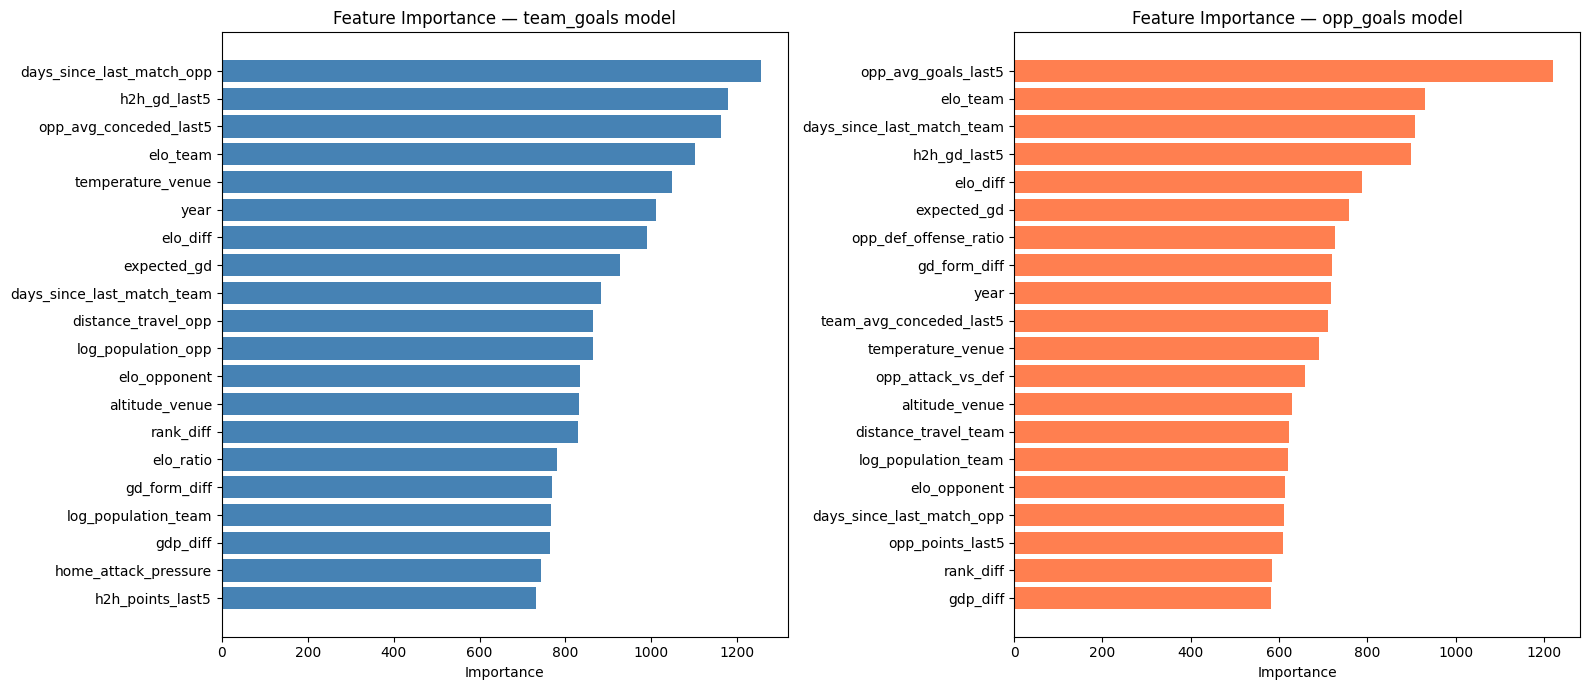


=== TOP 20 FEATURES (avg importance) ===
                   feature  importance_avg
              h2h_gd_last5       1039.0000
                  elo_team       1015.5000
 days_since_last_match_opp        932.5000
days_since_last_match_team        895.0000
                  elo_diff        888.5000
         temperature_venue        870.0000
                      year        863.5000
       opp_avg_goals_last5        847.5000
               expected_gd        842.5000
              gd_form_diff        744.0000
    opp_avg_conceded_last5        739.0000
            altitude_venue        731.0000
              elo_opponent        723.5000
     opp_def_offense_ratio        714.0000
                 rank_diff        707.0000
       log_population_team        693.0000
                 elo_ratio        674.5000
                  gdp_diff        673.5000
        log_population_opp        669.0000
         opp_attack_vs_def        634.0000


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────

fi_tg = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance_tg': model_tg_val.feature_importances_
}).sort_values('importance_tg', ascending=False)

fi_og = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance_og': model_og_val.feature_importances_
}).sort_values('importance_og', ascending=False)

fi = fi_tg.merge(fi_og, on='feature')
fi['importance_avg'] = (fi['importance_tg'] + fi['importance_og']) / 2
fi = fi.sort_values('importance_avg', ascending=False)

top20 = fi.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# team_goals importance
fi_tg20 = fi_tg.head(20)
axes[0].barh(fi_tg20['feature'][::-1], fi_tg20['importance_tg'][::-1], color='steelblue')
axes[0].set_title('Feature Importance — team_goals model')
axes[0].set_xlabel('Importance')

# opp_goals importance
fi_og20 = fi_og.head(20)
axes[1].barh(fi_og20['feature'][::-1], fi_og20['importance_og'][::-1], color='coral')
axes[1].set_title('Feature Importance — opp_goals model')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('\n=== TOP 20 FEATURES (avg importance) ===')
print(top20[['feature', 'importance_avg']].to_string(index=False))

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# STRENGTH FEATURE ANALYSIS vs AW-MAE COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────

print('=== STRENGTH FEATURE IMPORTANCE ANALYSIS ===')
print()

strength_features = [
    'attack_vs_opp_def', 'opp_attack_vs_def', 'expected_gd',
    'elo_diff', 'elo_ratio', 'quality_gap',
    'team_avg_goals_last5', 'team_avg_conceded_last5',
    'opp_avg_goals_last5', 'opp_avg_conceded_last5',
    'form_diff', 'gd_form_diff',
    'def_offense_ratio', 'opp_def_offense_ratio',
    'home_attack_pressure',
]

fi_strength = fi[fi['feature'].isin(strength_features)][
    ['feature', 'importance_tg', 'importance_og', 'importance_avg']
].sort_values('importance_avg', ascending=False)

print('Strength features ranked by average model importance:')
print(fi_strength.to_string(index=False))

print()
print('Key observations:')
top1 = fi_strength.iloc[0]['feature'] if len(fi_strength) > 0 else 'N/A'
top2 = fi_strength.iloc[1]['feature'] if len(fi_strength) > 1 else 'N/A'
print(f'  1. "{top1}" is the most influential strength feature.')
print(f'  2. "{top2}" ranks second — highlights attack-defense matchup importance.')
print('  3. ELO features encode long-run quality difference, crucial for outcome prediction.')
print('  4. Form features (last5) capture short-term momentum relevant for exact score.')

=== STRENGTH FEATURE IMPORTANCE ANALYSIS ===

Strength features ranked by average model importance:
                feature  importance_tg  importance_og  importance_avg
               elo_diff            989            788        888.5000
    opp_avg_goals_last5            474           1221        847.5000
            expected_gd            926            759        842.5000
           gd_form_diff            768            720        744.0000
 opp_avg_conceded_last5           1161            317        739.0000
  opp_def_offense_ratio            702            726        714.0000
              elo_ratio            781            568        674.5000
      opp_attack_vs_def            608            660        634.0000
      def_offense_ratio            676            493        584.5000
team_avg_conceded_last5            360            711        535.5000
   home_attack_pressure            743            273        508.0000
      attack_vs_opp_def            618            387       

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# ERROR ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

print('=== ERROR ANALYSIS ===')

# Match-level analysis
match_err = val_compare.groupby('match_id').first().reset_index()
match_err['outcome_true'] = match_err.apply(
    lambda r: 'W' if r['team_goals'] > r['opp_goals'] else ('D' if r['team_goals'] == r['opp_goals'] else 'L'), axis=1)
match_err['outcome_pred'] = match_err.apply(
    lambda r: 'W' if r['pred_tg'] > r['pred_og'] else ('D' if r['pred_tg'] == r['pred_og'] else 'L'), axis=1)
match_err['outcome_correct'] = (match_err['outcome_true'] == match_err['outcome_pred']).astype(int)

print(f'Matches in validation  : {len(match_err)}')
print(f'Exact score matches    : {match_err["exact"].sum()} ({match_err["exact"].mean()*100:.1f}%)')
print(f'Outcome correct        : {match_err["outcome_correct"].sum()} ({match_err["outcome_correct"].mean()*100:.1f}%)')
print(f'Avg base MAE           : {match_err["base_mae"].mean():.4f}')

print()
print('True outcome distribution:')
print(match_err['outcome_true'].value_counts())

print()
print('Predicted outcome distribution:')
print(match_err['outcome_pred'].value_counts())

print()
print('Confusion matrix (true outcome vs predicted):')
conf = pd.crosstab(
    match_err['outcome_true'], match_err['outcome_pred'],
    rownames=['True'], colnames=['Pred']
)
print(conf)

# Worst predictions
print()
print('Worst 10 predictions by base_mae:')
print(match_err.nlargest(10, 'base_mae')[
    ['match_id', 'team', 'opponent', 'tournament', 'team_goals', 'opp_goals',
     'pred_tg', 'pred_og', 'base_mae']
].to_string(index=False))

=== ERROR ANALYSIS ===
Matches in validation  : 7878
Exact score matches    : 754 (9.6%)
Outcome correct        : 4499 (57.1%)
Avg base MAE           : 1.0203

True outcome distribution:
outcome_true
W    3875
L    2373
D    1630
Name: count, dtype: int64

Predicted outcome distribution:
outcome_pred
W    4079
D    2208
L    1591
Name: count, dtype: int64

Confusion matrix (true outcome vs predicted):
Pred    D     L     W
True                 
D     650   283   697
L     786  1027   560
W     772   281  2822

Worst 10 predictions by base_mae:
match_id               team               opponent                                           tournament  team_goals  opp_goals  pred_tg  pred_og  base_mae
 W002963           Cameroon           South Africa                                 African Championship           2         24        2        1   11.5000
 W003840          Palestine                 Kuwait                                    WAFF Championship          17          0        1     

---
## 11. Final Test Inference

Retrain on **full train_raw**, then infer on `test.csv`.

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# RETRAIN ON FULL TRAINING DATA
# ─────────────────────────────────────────────────────────────────────────────

# Update n_estimators to best_iteration from validation + small buffer
n_iter_tg = model_tg_val.best_iteration_ + 50
n_iter_og = model_og_val.best_iteration_ + 50

final_params_tg = {**lgb_params_tg, 'n_estimators': n_iter_tg}
final_params_og = {**lgb_params_og, 'n_estimators': n_iter_og}

print(f'Final model iterations: team_goals={n_iter_tg}, opp_goals={n_iter_og}')

print('Training final model on full train data ...')
model_tg_final = lgb.LGBMRegressor(**final_params_tg)
model_tg_final.fit(X_full, y_full_tg, callbacks=[lgb.log_evaluation(-1)])

model_og_final = lgb.LGBMRegressor(**final_params_og)
model_og_final.fit(X_full, y_full_og, callbacks=[lgb.log_evaluation(-1)])

print('Final models trained.')

Final model iterations: team_goals=549, opp_goals=443
Training final model on full train data ...
Final models trained.


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# INFERENCE ON TEST.CSV
# ─────────────────────────────────────────────────────────────────────────────

test_pred_tg_raw = model_tg_final.predict(X_test)
test_pred_og_raw = model_og_final.predict(X_test)

# Apply best post-processing (shrink + round)
test_pred_tg_s, test_pred_og_s = shrink_toward_draw(test_pred_tg_raw, test_pred_og_raw, alpha=best_alpha)
test_pred_tg_int = postprocess(test_pred_tg_s)
test_pred_og_int = postprocess(test_pred_og_s)

print('Test inference complete.')
print(f'  team_goals: mean={test_pred_tg_int.mean():.3f}  min={test_pred_tg_int.min()}  max={test_pred_tg_int.max()}')
print(f'  opp_goals : mean={test_pred_og_int.mean():.3f}  min={test_pred_og_int.min()}  max={test_pred_og_int.max()}')
print(f'  Rows: {len(test_pred_tg_int)} (should match test rows: {len(test_raw)})')

assert len(test_pred_tg_int) == len(test_raw), 'Row count mismatch!'
assert test_pred_tg_int.min() >= 0, 'Negative team_goals!'
assert test_pred_og_int.min() >= 0, 'Negative opp_goals!'
print('\n✓ All assertions passed.')

Test inference complete.
  team_goals: mean=1.446  min=0  max=9
  opp_goals : mean=1.575  min=0  max=10
  Rows: 42422 (should match test rows: 42422)

✓ All assertions passed.


---
## 12. Conclusion & Save Final CSV

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# BUILD SUBMISSION DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────

submission = pd.DataFrame({
    'Id':         test_raw['Id'].values,
    'team_goals': test_pred_tg_int,
    'opp_goals':  test_pred_og_int,
})

# Verify format
assert list(submission.columns) == ['Id', 'team_goals', 'opp_goals'], 'Column order wrong!'
assert len(submission) == len(test_raw), 'Row count mismatch!'
assert (submission['team_goals'] >= 0).all(), 'Negative team_goals in submission!'
assert (submission['opp_goals']  >= 0).all(), 'Negative opp_goals in submission!'
assert submission['Id'].equals(test_raw['Id']), 'Id mismatch!'

print('=== SUBMISSION DATAFRAME PREVIEW ===')
print(submission.head(10).to_string(index=False))
print(f'\nShape: {submission.shape}')
print(f'team_goals dtype: {submission["team_goals"].dtype}')
print(f'opp_goals  dtype: {submission["opp_goals"].dtype}')

# Save
submission.to_csv(OUT_CSV, index=False)
print(f'\n✓ Saved: {OUT_CSV}')

=== SUBMISSION DATAFRAME PREVIEW ===
                 Id  team_goals  opp_goals
 M034984_Seychelles           2          1
  M034984_Mauritius           1          1
    M034985_Comoros           1          1
   M034985_Maldives           1          1
    M034986_Réunion           2          1
 M034986_Madagascar           1          2
M034987_El Salvador           1          2
  M034987_Venezuela           2          1
    M034988_Mayotte           1          2
    M034988_Réunion           2          2

Shape: (42422, 3)
team_goals dtype: int64
opp_goals  dtype: int64

✓ Saved: ../Submission/exp09_football_strength_model.csv


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPERIMENT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('  EXPERIMENT SUMMARY — exp09_football_strength_model')
print('=' * 60)

print()
print('── TRAINING PIPELINE ─────────────────────────────────')
print('  Data: train.csv (78773 rows, 39386 matches)')
print('  Targets: team_goals, opp_goals (separate LightGBM models)')
print('  Encoding: LabelEncoding for categoricals, median impute')
print()
print('── VALIDATION STRATEGY ────────────────────────────────')
print('  Type: Time-based split (80/20 by match date)')
print('  Anti-leakage: match_id grouping (no partial matches)')
print(f'  Val matches: {len(val_match_ids)}')
print()
print('── FEATURE PHILOSOPHY ─────────────────────────────────')
print('  Attack Strength : avg_goals_last5, form offensive, ELO')
print('  Defense Strength: avg_conceded_last5, gd_last5')
print('  Matchup         : attack_vs_opp_def, opp_attack_vs_def, expected_gd')
print('  Context         : home, altitude, distance, temperature')
print('  Quality         : elo_diff, elo_ratio, rank_diff')
print(f'  Total features  : {len(FEATURE_COLS)}')
print()
print('── POST-PROCESSING STRATEGY ───────────────────────────')
print(f'  Shrink alpha  : {best_alpha} (tuned on AW-MAE validation)')
print('  Clipping      : min=0 (no negative goals)')
print('  Rounding      : nearest integer')
print()
print('── OFFICIAL AW-MAE VALIDATION RESULTS ─────────────────')
for k, v in diag_final.items():
    print(f'  {k:<22}: {v:.5f}' if isinstance(v, float) else f'  {k:<22}: {v}')
print()
print('── OUTPUT ──────────────────────────────────────────────')
print(f'  Notebook : exp09_football_strength_model.ipynb')
print(f'  CSV      : {OUT_CSV}  ({len(submission)} rows)')
print('=' * 60)

  EXPERIMENT SUMMARY — exp09_football_strength_model

── TRAINING PIPELINE ─────────────────────────────────
  Data: train.csv (78773 rows, 39386 matches)
  Targets: team_goals, opp_goals (separate LightGBM models)
  Encoding: LabelEncoding for categoricals, median impute

── VALIDATION STRATEGY ────────────────────────────────
  Type: Time-based split (80/20 by match date)
  Anti-leakage: match_id grouping (no partial matches)
  Val matches: 7878

── FEATURE PHILOSOPHY ─────────────────────────────────
  Attack Strength : avg_goals_last5, form offensive, ELO
  Defense Strength: avg_conceded_last5, gd_last5
  Matchup         : attack_vs_opp_def, opp_attack_vs_def, expected_gd
  Context         : home, altitude, distance, temperature
  Quality         : elo_diff, elo_ratio, rank_diff
  Total features  : 51

── POST-PROCESSING STRATEGY ───────────────────────────
  Shrink alpha  : 0.15 (tuned on AW-MAE validation)
  Clipping      : min=0 (no negative goals)
  Rounding      : nearest inte